# Titanic survival prediction with linear regression

This notebook estimates survival probability from **gender**, **age**, and passenger **status/class** (`pclass`). Linear regression is used as requested: its continuous score is interpreted as a probability and thresholded at 0.5 for classification.

> Note: logistic regression is generally more appropriate for a binary outcome, but linear regression is used here as requested.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('titanic-2.csv')
df.head()

,survived,pclass,name,sex,age,fare,sibsp,parch
0,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,1,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,1,0
2,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,0,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,1,0
4,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,0,0


In [3]:
print(f'Rows and columns: {df.shape}')
display(df[['survived', 'sex', 'age', 'pclass']].describe(include='all'))
print('Missing values:\n', df[['survived', 'sex', 'age', 'pclass']].isna().sum())
print('Survival rate by gender:')
display(df.groupby('sex')['survived'].mean().rename('survival_probability'))
print('Survival rate by status/class:')
display(df.groupby('pclass')['survived'].mean().rename('survival_probability'))

Rows and columns: (714, 8)


,survived,sex,age,pclass
count,714.000000,714,714.000000,714.000000
unique,NaN,2,NaN,NaN
top,NaN,male,NaN,NaN
freq,NaN,453,NaN,NaN
mean,0.406162,NaN,29.699118,2.236695
std,0.491460,NaN,14.526497,0.838250
min,0.000000,NaN,0.420000,1.000000
25%,0.000000,NaN,20.125000,1.000000
50%,0.000000,NaN,28.000000,2.000000
75%,1.000000,NaN,38.000000,3.000000


Missing values:
 survived    0
sex         0
age         0
pclass      0
dtype: int64
Survival rate by gender:


sex
female    0.754789
male      0.205298
Name: survival_probability, dtype: float64

Survival rate by status/class:


pclass
1    0.655914
2    0.479769
3    0.239437
Name: survival_probability, dtype: float64

## Prepare features and split the data

`sex` is one-hot encoded, missing ages are replaced with the median, and `pclass` is used as the numeric status/class feature (1 = first class, 3 = third class).

In [4]:
features = ['sex', 'age', 'pclass']
X, y = df[features], df['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
preprocessor = ColumnTransformer(transformers=[
    ('numeric', SimpleImputer(strategy='median'), ['age', 'pclass']),
    ('gender', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))]), ['sex'])
])
model = Pipeline([('preprocessor', preprocessor), ('regressor', LinearRegression())])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['sex','age','pclass']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('gender', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the t

## Confusion matrix and ROC evaluation

The raw regression score is used for ROC-AUC. Predictions at least 0.5 are classified as survivors. Scores are clipped only when displayed as probabilities because linear regression can produce values outside the 0–1 range.

Accuracy: 0.783
RMSE: 0.383
ROC-AUC: 0.854

Classification report:
                 precision    recall  f1-score   support

Did not survive       0.81      0.82      0.82        85
       Survived       0.74      0.72      0.73        58

       accuracy                           0.78       143
      macro avg       0.78      0.77      0.77       143
   weighted avg       0.78      0.78      0.78       143



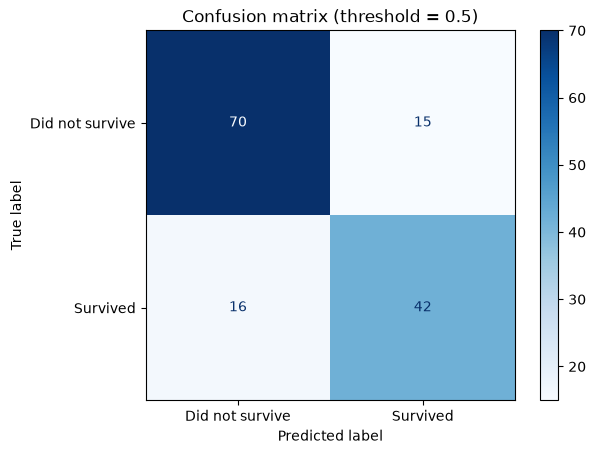

In [5]:
y_score = model.predict(X_test)
y_probability = np.clip(y_score, 0, 1)
y_pred = (y_score >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
auc = roc_auc_score(y_test, y_score)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'RMSE: {mean_squared_error(y_test, y_score) ** 0.5:.3f}')
print(f'ROC-AUC: {auc:.3f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['Did not survive', 'Survived']))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did not survive', 'Survived']).plot(cmap='Blues', values_format='d')
plt.title('Confusion matrix (threshold = 0.5)')
plt.show()

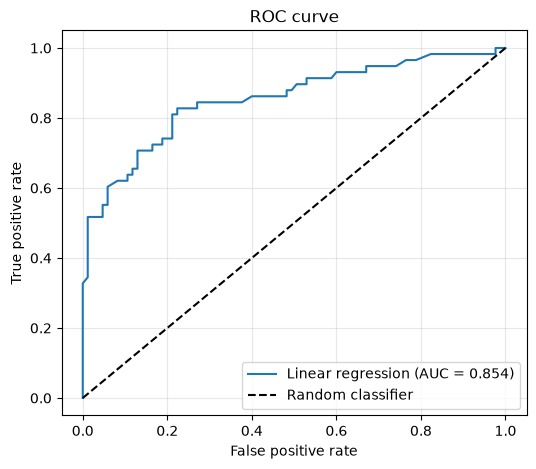

In [6]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Linear regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('ROC curve'); plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.show()

## Estimate survival probability for a passenger

Change the values below to estimate probability from gender, age, and status/class.

In [7]:
def survival_probability(gender, age, status):
    passenger = pd.DataFrame([{'sex': gender, 'age': age, 'pclass': status}])
    return float(np.clip(model.predict(passenger)[0], 0, 1))

examples = pd.DataFrame([
    {'sex': 'female', 'age': 30, 'pclass': 1}, {'sex': 'female', 'age': 30, 'pclass': 3},
    {'sex': 'male', 'age': 30, 'pclass': 1}, {'sex': 'male', 'age': 30, 'pclass': 3}
])
examples['estimated_survival_probability'] = examples.apply(lambda r: survival_probability(r['sex'], r['age'], r['pclass']), axis=1)
examples

,sex,age,pclass,estimated_survival_probability
0,female,30,1,0.958266
1,female,30,3,0.550084
2,male,30,1,0.484871
3,male,30,3,0.076689
